In [ ]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 22.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import control as ctrl
from matplotlib import pyplot as plt
import sympy as sp
from scipy import signal as signal

##TP1

In [ ]:
#Def de variables

m = 0.05
vm_eq = 45 #Hz
g = 9.8
a, b, c = 1e-8, 1.5e-6, 5e-5
l = 0.25
Kr = 0.05


tita_dot_eq = 0

#Simbolos de la planta
F, vm, tita, tita_dot, f1, f2, t = sp.symbols('F,vm,tita,tita_dot,f1,f2,t', real = True)

#Conversion vm de eq a fuerza y fuerza de eq a
F_eq = (a*vm_eq**4 + b*vm_eq**3 + c*vm_eq**2)*m*g

tita_eq = np.asin(F_eq/(m*g))

f1 = tita_dot
f2 = (F - m*g*sp.sin(tita) - Kr*tita_dot)/(m*l)

df1dtita = sp.diff(f1, tita)
df1dtita_dot = sp.diff(f1, tita_dot)
df2dtita = sp.diff(f2, tita)
df2dtita_dot = sp.diff(f2, tita_dot)

df1dF = sp.diff(f1, F)
df2dF = sp.diff(f2, F)

A = sp.Matrix([[df1dtita, df1dtita_dot], [df2dtita, df2dtita_dot]])
B = sp.Matrix([[df1dF], [df2dF]])

A = A.subs({tita: tita_eq, tita_dot: tita_dot_eq, F: F_eq, sp.cos(tita): np.cos(tita_eq)})
B = B.subs({tita: tita_eq, tita_dot: tita_dot_eq, F: F_eq})

C = [1, 0]
D = 0

print(A)
print(B)
print(C)
print(D)

Matrix([[0, 1], [-37.6440517503891, -4.00000000000000]])
Matrix([[0], [80.0000000000000]])
[1, 0]
0


In [ ]:
Ts = 0.02

G = ctrl.ss(A, B, C, D)

G_tf = ctrl.ss2tf(A, B, C, D)

print(G_tf)

print(ctrl.poles(G))
print(ctrl.zeros(G))
print('\n\n')

G_d = ctrl.c2d(G, Ts, 'zoh')

G_d_tf = ctrl.ss2tf(G_d.A, G_d.B, G_d.C, G_d.D)

print(G_d_tf)

print(ctrl.poles(G_d))
print(ctrl.zeros(G_d))
print('\n\n')



<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  -4.441e-16 s + 80
  -----------------
  s^2 + 4 s + 37.64
[-2.+5.80034928j -2.-5.80034928j]
[]



<TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.01556 s + 0.01515
  ----------------------
  s^2 - 1.909 s + 0.9231
[0.95433172+0.11120846j 0.95433172-0.11120846j]
[-0.97367394+0.j]





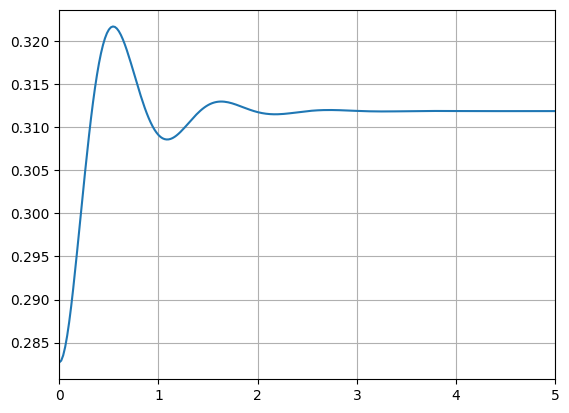

In [ ]:
#Simulacion no lineal

# Define the state update function for a continuous-time system
def updfcn(t, x, u, params):
    # Example: a simple nonlinear system
    # dx/dt = -x^2 + u
    return [x[1], (u[0] - m*g*sp.sin(x[0]) - Kr*x[1])/(m*l)]

# Define the output function (optional)
def outfcn(t, x, u, params):
    # Output is simply the state
    return x[0]

# Create the nonlinear system
sys = ctrl.nlsys(updfcn, outfcn, states=2, inputs=1, outputs=1)

# Simulate the system's response to a step input
T = np.linspace(0, 10, int(10/0.02))
U = np.ones_like(T)*(F_eq + F_eq*0.1) # Step input

X0 = [tita_eq, 0] # Initial state

t, y = ctrl.input_output_response(sys, T, U, X0)

plt.plot(t, y)
plt.xlim((0,5))
plt.grid(True)



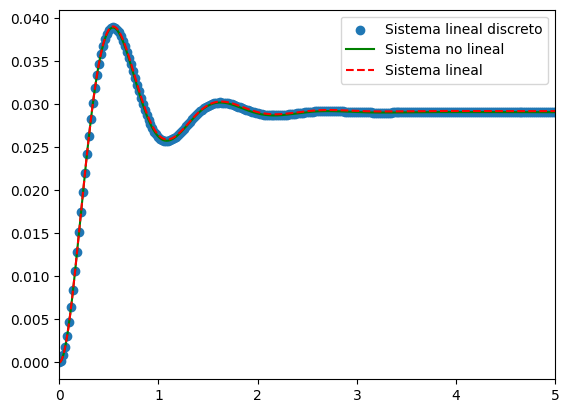

In [ ]:
T = np.arange(0, 10, Ts)

U = np.ones_like(T)*(F_eq*0.1)

t, y = ctrl.step_response(G_d, T, [0, 0])

plt.scatter(t, y*F_eq*0.1)

T = np.arange(0, 10, 0.01)

U = np.ones_like(T)*(F_eq*0.1)

t, y = ctrl.input_output_response(G, T, U, [0, 0])

plt.plot(t, y, 'g')

T = np.linspace(0, 10, int(10/0.01))
U = np.ones_like(T)*(F_eq + F_eq*0.1) # Step input

X0 = [tita_eq, 0] # Initial state

t, y = ctrl.input_output_response(sys, T, U, X0)

plt.plot(t, y - tita_eq, "r--")

plt.xlim ((0,5))

plt.legend(['Sistema lineal discreto', 'Sistema no lineal', 'Sistema lineal'])


/usr/local/lib/python3.12/dist-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


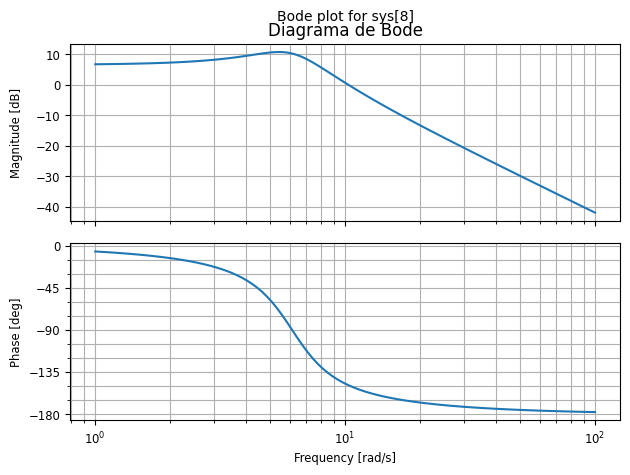

In [ ]:
# Supongamos que ya definiste A, B, C, D
G1 = ctrl.ss2tf(A, B, C, D)

# Definir rango de frecuencias (log-spaced entre 10^0 y 10^6 rad/s)
omega = np.logspace(0, 2, 100)  # de 1 a 10^6 rad/s

# Bode plot limitado
mag, phase, omega = ctrl.bode(G1, omega=omega, dB=True, Hz=False, deg=True, plot=True)

fig = plt.gcf()
axes = fig.get_axes()

axes[0].set_title("Diagrama de Bode")
plt.show()


#TP2

## Estimación de respuesta al impulso por correlación

Media de urb=0.00178
Varianza de urb=0.9999968316000002


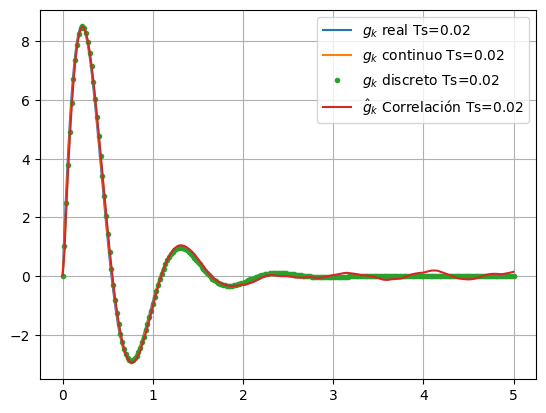

In [ ]:
M = 500 # cantidad de coeficientes a estimar

# Entrada impulso
u_delta = np.zeros(M)
u_delta[0] = 1
g_real = ctrl.impulse_response(G, T=np.arange(0,M*Ts,Ts))[1]
g = ctrl.forced_response(G, T=np.arange(0,M*Ts,Ts), U=u_delta*2)[1]
gd = ctrl.forced_response(G_d, T=np.arange(0,M*Ts,Ts), U=u_delta)[1]


# Genero una señal aleatoria binaria de media 0 y varianza 1
N = 100000
urb = np.sign(np.random.randn(N))
print(f"Media de urb={np.mean(urb)}")
print(f"Varianza de urb={np.var(urb)}")

e = 0.01*np.random.randn(N)

ruu = np.correlate(urb, urb, mode="full")/N  # correlación completa
mid = len(ruu)//2
lags = np.arange(-M//2,M//2+1)

tt=np.arange(0,N*Ts,Ts)
y_u = ctrl.forced_response(G_d, T=tt, U=urb)[1]
y = y_u + e

ryu = np.correlate(y, urb, mode="full")/N  # correlación completa
g_hat_corr = ryu[mid+np.arange(0,M)]

# Graficar
idx_lag = np.arange(0,M//2+1)
plt.plot(idx_lag*Ts,g_real[idx_lag],'-', label=f'$g_k$ real Ts={Ts}')
plt.plot(idx_lag*Ts,g[idx_lag]/Ts,'-', label=f'$g_k$ continuo Ts={Ts}')
plt.plot(idx_lag*Ts,g[idx_lag]/Ts,'.', label=f'$g_k$ discreto Ts={Ts}')
plt.plot(idx_lag*Ts,g_hat_corr[idx_lag]/Ts,'-',label=f'$\\hat{{g}}_k$ Correlación Ts={Ts}')

plt.legend()
plt.grid()
plt.show()

## Estimación de la respuesta en frecuencia por espectrograma

<>:38: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-745487969.py:38: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ [rad/s]')
/usr/local/lib/python3.12/dist-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


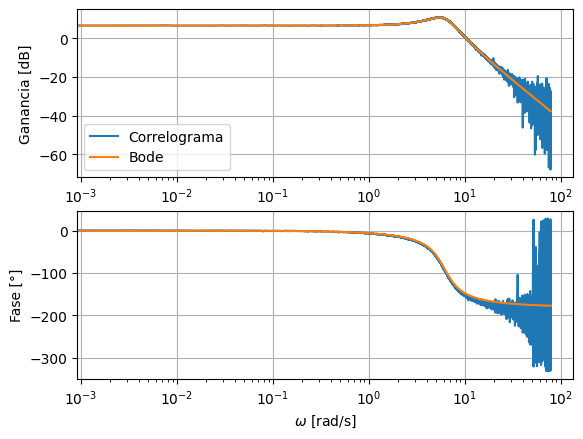

In [ ]:
from scipy.signal import csd, welch

window = True
plot=True

win = np.ones_like(ruu)
if window:
    win = signal.windows.hann(len(ruu))

Puy = np.fft.fft(ryu*win)
Puu = np.fft.fft(ruu*win)
w = np.fft.fftfreq(len(ruu), Ts)*2*np.pi
G_corr = Puy/Puu

mag_ident= np.abs(G_corr[0:N//2])
phase_ident = np.angle(G_corr[0:N//2])
phase_ident = np.where(phase_ident > 0.5, phase_ident - 2*np.pi, phase_ident)
phase_ident *= 180/np.pi
w_ident = w[0:N//2]


mag, phase, w_calc = ctrl.bode(G, w_ident, plot=False)

if plot:
    plt.figure()
    plt.subplot(211)
    plt.semilogx(w_ident,20*np.log10(mag_ident),label='Correlograma')
    plt.semilogx(w_calc,20*np.log10(mag),label='Bode')
    #plt.xlim(w_min,w_max)
    plt.ylabel('Ganancia [dB]')
    plt.legend()
    plt.grid()
    plt.subplot(212)
    plt.semilogx(w_ident,phase_ident,label='Correlograma')
    plt.semilogx(w_calc,phase*180/np.pi,label='Bode')
    #plt.xlim(w_min,w_max)
    plt.ylabel('Fase [°]')
    plt.xlabel('$\omega$ [rad/s]')
    #plt.legend()
    plt.grid()


## Ec en diferencias de la planta

Se imprime la transferencia de la planta para obtener la forma de la ecuación en diferencias

$$ y_k = a_1 \, y_{k-1} + a_2 \, y_{k-2} + b_1 \, u_{k-1} + b_2 u_{k-2}$$

In [ ]:
print(ctrl.ss2tf(G_d))

<TransferFunction>: sys[0]$sampled$converted
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

   0.01556 z + 0.01515
  ----------------------
  z^2 - 1.909 z + 0.9231


Se genera un simulador de la planta con la ecuación en diferencia y pudiendo elegir diferentes modelos para corroborar los algoritmos

In [ ]:
def obtener_datos(u ,e ,a1, a2, b1, b2, C, type='ARX'):
  N = len(u)
  y = np.zeros_like(u)
  if type=='ARX':
    for k in range(2, N):
      y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1] + b2*u[k-2] + e[k]
  elif type=='ARMAX':
    for k in range(2, N):
      y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1] + b2*u[k-2] + e[k] + C*e[k-1]
  elif type=='OE':
    for k in range(2, N):
      y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1] + b2*u[k-2]
    y = y + e;

  return y

##Estimación por RLS

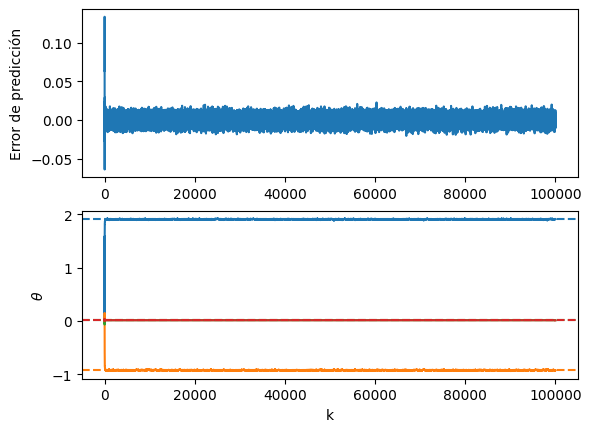

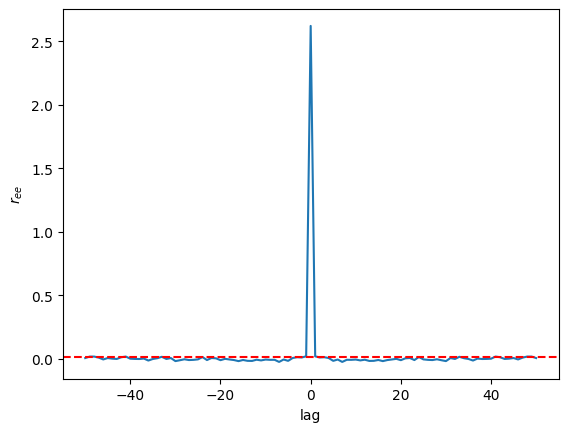

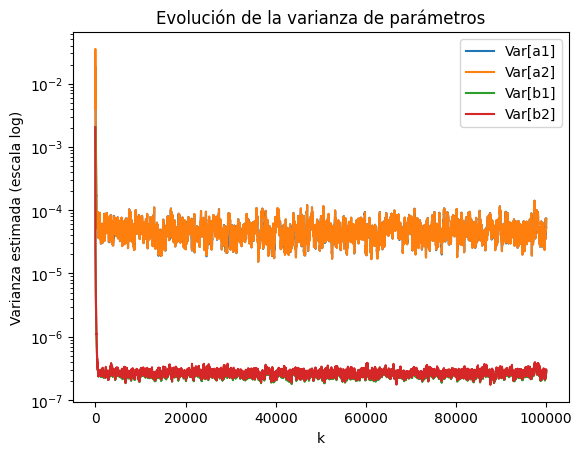

In [ ]:
def estimador_RLS(u,y,na=1, nb=1, lambda_=1,theta_real=None,plot=True):
    N = len(u)
    theta_hat = np.zeros(na+nb)       # estimación inicial [a_hat, b_hat]
    P = 100 * np.eye(na+nb)          # matriz de covarianza grande
    err = np.zeros_like(y)

    lambda_sigma = 0.99
    sigma2_hat = 0.0

    theta_hist = []
    P_hist = []
    sigma2_hist = []

    k_range = range(na+1, N)
    for k in k_range:
        phi = np.concatenate((y[k-1:k-na-1:-1], u[k-1:k-nb-1:-1]))   # vector de regresores
        y_hat = phi @ theta_hat
        err[k] = y[k] - y_hat

        K = P @ phi / (lambda_ + phi.T @ P @ phi)
        theta_hat = theta_hat + K * err[k]
        P = (P - np.outer(K, phi) @ P) / lambda_
        sigma2_hat = lambda_sigma * sigma2_hat + (1 - lambda_sigma) * (err[k]**2)
        sigma2_hist.append(sigma2_hat)

        theta_hist.append(theta_hat.copy())
        P_hist.append(np.diag(P).copy())

    theta_hist = np.array(theta_hist)
    P_hist = np.array(P_hist)
    sigma2_hist = np.array(sigma2_hist)

    if plot:
        plt.subplot(211)
        plt.step(k_range,err[k_range],where='post')
        #plt.xlabel('Tiempo [s]')
        plt.ylabel('Error de predicción')
        plt.subplot(212)
        for idx_na in range(0,na):
            plt.step(k_range,theta_hist[:,idx_na], label=f"$\\hat{{a_{idx_na+1}}}$",where='post')
        for idx_nb in range(0,nb):
            plt.step(k_range,theta_hist[:,na+idx_nb], label=f"$\\hat{{b_{idx_nb+1}}}$",where='post')
        if theta_real!=None:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
            for idx_na in range(na):
                color = colors[idx_na % len(colors)]
                plt.axhline(theta_real[idx_na], linestyle='--', color=color, label=f"$a_{idx_na}$")
            for idx_nb in range(nb):
                color = colors[(idx_nb+na) % len(colors)]
                plt.axhline(theta_real[idx_nb+na], linestyle='--', color=color, label=f"$b_{idx_nb}$")
        #plt.legend()
        plt.xlabel('k')
        plt.ylabel('$\\theta$')
        plt.show()

        # Observemos la correlación del error de predicción
        N_lag = 50
        ree = np.correlate(err,err,'full')
        lags = np.arange(-len(err)+1, len(err))
        center = len(ree) // 2
        ree = ree[center-N_lag:center+N_lag+1]
        lags_plot = lags[center-N_lag:center+N_lag+1]
        ree_max_val = 2.17/np.sqrt(N)*ree[N_lag]
        plt.figure()
        plt.plot(lags_plot,ree)
        plt.ylabel('$r_{{ee}}$')
        plt.xlabel('lag')
        plt.axhline(ree_max_val, linestyle='--', color='r', label=f"$ree_{{max}}$")
        plt.plot()

        var_a1 = sigma2_hist * P_hist[:,0]
        var_a2 = sigma2_hist * P_hist[:,1]
        var_b1 = sigma2_hist * P_hist[:,2]
        var_b2 = sigma2_hist * P_hist[:,3]

        plt.figure()
        plt.semilogy(var_a1, label='Var[a1]')
        plt.semilogy(var_a2, label='Var[a2]')
        plt.semilogy(var_b1, label='Var[b1]')
        plt.semilogy(var_b2, label='Var[b2]')
        plt.xlabel('k')
        plt.ylabel('Varianza estimada (escala log)')
        plt.legend()
        plt.title('Evolución de la varianza de parámetros')
        plt.show()


        return theta_hist,P

N = 100000
urb = np.sign(np.random.randn(N))
e = 0.005*np.random.randn(N)
y = obtener_datos(urb, e, 1.909, -0.9231, 0.01556, 0.01515, 0.01, type='ARX')
theta_hat,P = estimador_RLS(urb,y,lambda_=0.99,na=2,nb=2, theta_real=[1.909, -0.9231, 0.01556, 0.01515])

##Comparación de rta al escalón

<TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = True

    0.01608 z + 0.0147
  ----------------------
  z^2 - 1.915 z + 0.9285


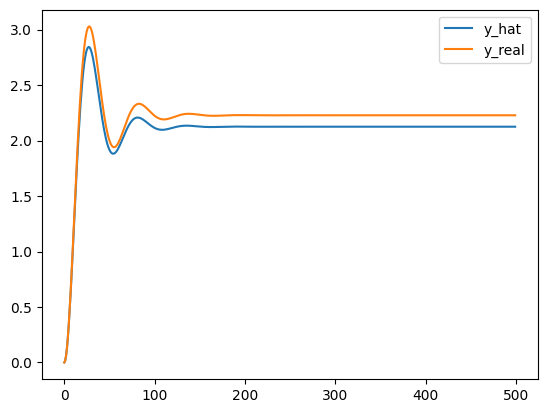

In [ ]:
z = ctrl.tf('z')

G_hat = (theta_hat[-1,2]*z + theta_hat[-1,3])/(-theta_hat[-1,1] - theta_hat[-1,0]*z + z*z)

print(G_hat)

N_val = 500

y_hat_val = ctrl.step_response(G_d, T=np.arange(0,N_val*Ts,Ts))[1]
y_real_val = ctrl.step_response(G_hat, T=np.arange(0,N_val*Ts,Ts))[1]

y_err_val = y_real_val - y_hat_val

plt.plot(y_hat_val, label='y_hat')
plt.plot(y_real_val, label='y_real')
plt.legend()
plt.show()


## Estimador ELS para ruido coloreado

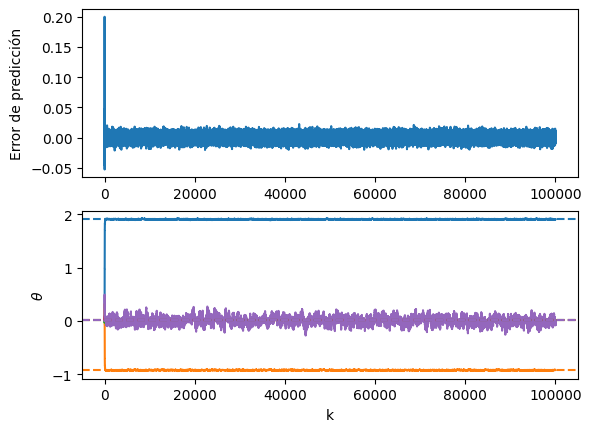

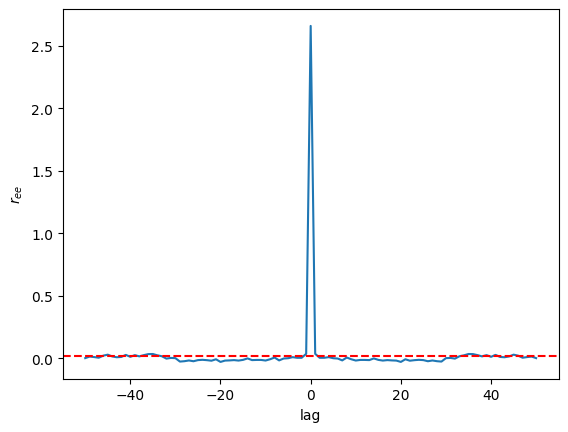

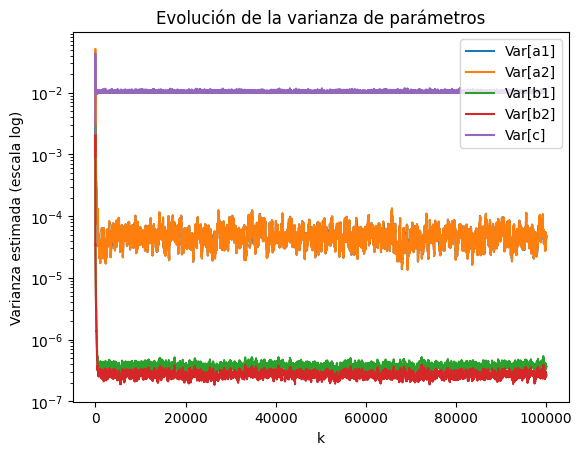

In [ ]:
# Estimador por mínimos cuadrados extendido para un modelo ARX con ruido coloreado
def estimador_ELS(u,y,na=1, nb=1, nc=1, lambda_=1,theta_real=None,plot=True):
    N = len(u)
    theta_hat = np.zeros(na+nb+nc)       # estimación inicial [a_hat, b_hat]
    P = 100 * np.eye(na+nb+nc)          # matriz de covarianza grande
    err = np.zeros_like(y)

    lambda_sigma = 0.99
    sigma2_hat = 0.0

    theta_hist = []
    P_hist = []
    sigma2_hist = []

    k_range = range(na+1, N)
    for k in k_range:
        phi = np.concatenate((y[k-1:k-na-1:-1], u[k-1:k-nb-1:-1], err[k-1:k-nc-1:-1]))   # vector de regresores
        phi[2] = np.sin(phi[2])
        y_hat = phi @ theta_hat
        err[k] = y[k] - y_hat

        K = P @ phi / (lambda_ + phi.T @ P @ phi)
        theta_hat = theta_hat + K * err[k]
        P = (P - np.outer(K, phi) @ P) / lambda_

        sigma2_hat = lambda_sigma * sigma2_hat + (1 - lambda_sigma) * (err[k]**2)
        sigma2_hist.append(sigma2_hat)

        theta_hist.append(theta_hat.copy())
        P_hist.append(np.diag(P).copy())

    theta_hist = np.array(theta_hist)
    P_hist = np.array(P_hist)
    sigma2_hist = np.array(sigma2_hist)

    if plot:
        plt.subplot(211)
        plt.step(k_range,err[k_range],where='post')
        #plt.xlabel('Tiempo [s]')
        plt.ylabel('Error de predicción')
        plt.subplot(212)
        for idx_na in range(0,na):
            plt.step(k_range,theta_hist[:,idx_na], label=f"$\\hat{{a_{idx_na+1}}}$",where='post')
        for idx_nb in range(0,nb):
            plt.step(k_range,theta_hist[:,na+idx_nb], label=f"$\\hat{{b_{idx_nb+1}}}$",where='post')
        for idx_nc in range(0,nc):
            plt.step(k_range,theta_hist[:,na+nb+idx_nc], label=f"$\\hat{{c_{idx_nc+1}}}$",where='post')
        if theta_real!=None:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
            for idx_na in range(na):
                color = colors[idx_na % len(colors)]
                plt.axhline(theta_real[idx_na], linestyle='--', color=color, label=f"$a_{idx_na}$")
            for idx_nb in range(nb):
                color = colors[(idx_nb+na) % len(colors)]
                plt.axhline(theta_real[idx_nb+na], linestyle='--', color=color, label=f"$b_{idx_nb}$")
            for idx_nc in range(nc):
                color = colors[(idx_nc+na+nb) % len(colors)]
                plt.axhline(theta_real[idx_nc+na+nb], linestyle='--', color=color, label=f"$c_{idx_nc}$")
        #plt.legend()
        plt.xlabel('k')
        plt.ylabel('$\\theta$')
        plt.show()

        # Observemos la correlación del error de predicción
        N_lag = 50
        ree = np.correlate(err,err,'full')
        lags = np.arange(-len(err)+1, len(err))
        center = len(ree) // 2
        ree = ree[center-N_lag:center+N_lag+1]
        lags_plot = lags[center-N_lag:center+N_lag+1]
        ree_max_val = 2.17/np.sqrt(N)*ree[N_lag]
        plt.figure()
        plt.plot(lags_plot,ree)
        plt.ylabel('$r_{{ee}}$')
        plt.xlabel('lag')
        plt.axhline(ree_max_val, linestyle='--', color='r', label=f"$ree_{{max}}$")
        plt.plot()

        var_a1 = sigma2_hist * P_hist[:,0]
        var_a2 = sigma2_hist * P_hist[:,1]
        var_b1 = sigma2_hist * P_hist[:,2]
        var_b2 = sigma2_hist * P_hist[:,3]
        var_c = sigma2_hist * P_hist[:,4]

        plt.figure()
        plt.semilogy(var_a1, label='Var[a1]')
        plt.semilogy(var_a2, label='Var[a2]')
        plt.semilogy(var_b1, label='Var[b1]')
        plt.semilogy(var_b2, label='Var[b2]')
        plt.semilogy(var_c, label='Var[c]')
        plt.xlabel('k')
        plt.ylabel('Varianza estimada (escala log)')
        plt.legend()
        plt.title('Evolución de la varianza de parámetros')
        plt.show()


        return theta_hist,P

N = 100000
urb = np.sign(np.random.randn(N))
e = 0.005*np.random.randn(N)
y = obtener_datos(urb, e, 1.909, -0.9231, 0.01556, 0.01515, 0.01, type='ARMAX')

theta_hat,P = estimador_ELS(urb,y,lambda_=0.99,na=2,nb=2,nc=1, theta_real=[1.909, -0.9231, 0.01556, 0.01515, 0.01])



## Estimador PEM para modelo OE

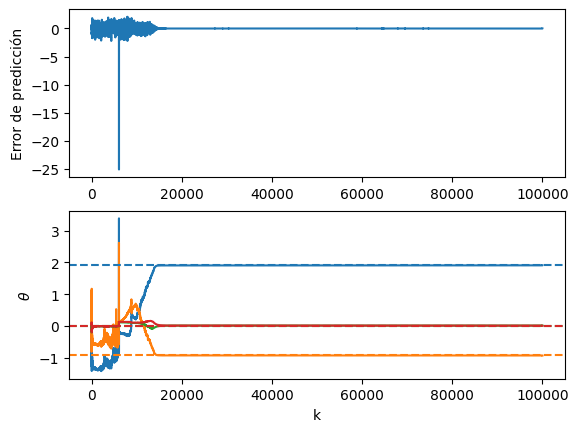

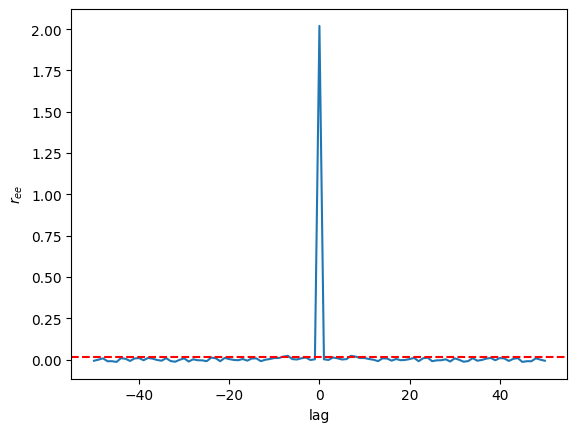

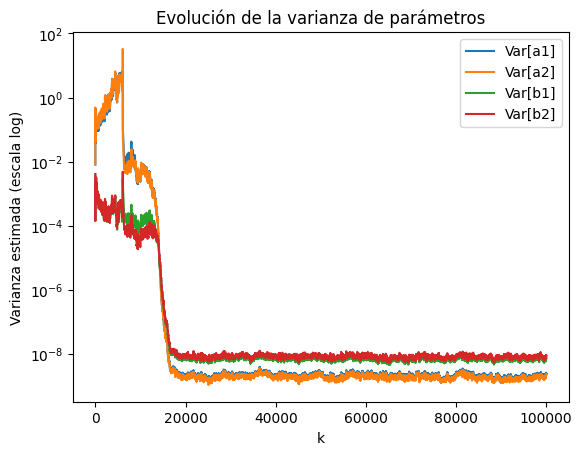

In [ ]:
def estimador_OE(u,y,na=1, nb=1, lambda_=1,theta_real=None,plot=True):
  theta = np.array([0.0, 0.0, 0.0, 0.0])  # [a, b] inicial
  P = np.eye(4) * 100.0        # covarianza inicial

  # Para simular predictor y sensibilidades (jacobiano del error de predicción)
  y_hat_prev = 0.0
  y_hat_prev_prev = 0.0
  s_a1_prev, s_b1_prev = 0.0, 0.0
  s_a1_prev_prev, s_b1_prev_prev = 0.0, 0.0
  s_a2_prev, s_b2_prev = 0.0, 0.0
  s_a2_prev_prev, s_b2_prev_prev = 0.0, 0.0
  sigma2_hat = 0.0
  lambda_sigma = 0.99  # para estimar varianza del ruido (recursivamente a partir de residuos)

  theta_hist = []
  P_hist = []
  sigma2_hist = []
  err = np.zeros_like(y)

  k_range = range(na+1, N)
  for k in k_range:
    # Predicción un paso adelante
    y_hat = theta[0] * y_hat_prev + theta[1] * y_hat_prev_prev  + theta[2] * urb[k-1] + theta[3] * urb[k-2]

    # Error de predicción
    err[k] = y[k] - y_hat

    # Cálculo de sensibilidades (recursivas)
    s_a1 = y_hat_prev + theta[0] * s_a1_prev + theta[1] * s_a1_prev_prev
    s_a2 = y_hat_prev_prev + theta[1] * s_a2_prev_prev + theta[0] * s_a2_prev
    s_b1 = urb[k-1] + theta[0] * s_b1_prev + theta[1] * s_b1_prev_prev
    s_b2 = urb[k-2] + theta[1] * s_b2_prev_prev + theta[0] * s_b2_prev

    # Escribo el vector regresor con las sensibilidades. De esta forma el costo es lineal en theta
    phi = np.array([s_a1, s_a2, s_b1, s_b2])

    # Formulas de actualización de mínimos cuadrados recursivos
    denom = lambda_ + phi @ P @ phi
    K = (P @ phi) / denom
    theta = theta + K * err[k]

    P = (1/lambda_) * (np.eye(4) - np.outer(K, phi)) @ P

    # update estados para próxima iteración
    y_hat_prev_prev = y_hat_prev
    y_hat_prev = y_hat
    s_a2_prev_prev, s_b2_prev_prev = s_a2_prev, s_b2_prev
    s_a2_prev, s_b2_prev = s_a2, s_b2
    s_a1_prev_prev, s_b1_prev_prev = s_a1_prev, s_b1_prev
    s_a1_prev, s_b1_prev = s_a1, s_b1

    # Estimación recursiva de varianza del ruido
    sigma2_hat = lambda_sigma * sigma2_hat + (1 - lambda_sigma) * (err[k]**2)
    sigma2_hist.append(sigma2_hat)

    # guardar historial
    theta_hist.append(theta.copy())
    P_hist.append(np.diag(P).copy())


  theta_hist = np.array(theta_hist)
  P_hist = np.array(P_hist)
  sigma2_hist = np.array(sigma2_hist)

  if plot:
      plt.subplot(211)
      plt.step(k_range,err[k_range],where='post')
      #plt.xlabel('Tiempo [s]')
      plt.ylabel('Error de predicción')
      plt.subplot(212)
      for idx_na in range(0,na):
          plt.step(k_range,theta_hist[:,idx_na], label=f"$\\hat{{a_{idx_na+1}}}$",where='post')
      for idx_nb in range(0,nb):
          plt.step(k_range,theta_hist[:,na+idx_nb], label=f"$\\hat{{b_{idx_nb+1}}}$",where='post')
      if theta_real!=None:
          colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
          for idx_na in range(na):
              color = colors[idx_na % len(colors)]
              plt.axhline(theta_real[idx_na], linestyle='--', color=color, label=f"$a_{idx_na}$")
          for idx_nb in range(nb):
              color = colors[(idx_nb+na) % len(colors)]
              plt.axhline(theta_real[idx_nb+na], linestyle='--', color=color, label=f"$b_{idx_nb}$")
      #plt.legend()
      plt.xlabel('k')
      plt.ylabel('$\\theta$')
      plt.show()

      # Observemos la correlación del error de predicción
      N_lag = 50
      ree = np.correlate(err[20000:],err[20000:],'full')
      lags = np.arange(-len(err[20000:])+1, len(err[20000:]))
      center = len(ree) // 2
      ree = ree[center-N_lag:center+N_lag+1]
      lags_plot = lags[center-N_lag:center+N_lag+1]
      ree_max_val = 2.17/np.sqrt(N)*ree[N_lag]
      plt.figure()
      plt.plot(lags_plot,ree)
      plt.ylabel('$r_{{ee}}$')
      plt.xlabel('lag')
      plt.axhline(ree_max_val, linestyle='--', color='r', label=f"$ree_{{max}}$")
      plt.plot()

      var_a1 = sigma2_hist * P_hist[:,0]
      var_a2 = sigma2_hist * P_hist[:,1]
      var_b1 = sigma2_hist * P_hist[:,2]
      var_b2 = sigma2_hist * P_hist[:,3]

      plt.figure()
      plt.semilogy(var_a1, label='Var[a1]')
      plt.semilogy(var_a2, label='Var[a2]')
      plt.semilogy(var_b1, label='Var[b1]')
      plt.semilogy(var_b2, label='Var[b2]')
      plt.xlabel('k')
      plt.ylabel('Varianza estimada (escala log)')
      plt.legend()
      plt.title('Evolución de la varianza de parámetros')
      plt.show()


      return theta_hist,P

N = 100000
urb = np.sign(np.random.randn(N))
e = 0.005*np.random.randn(N)
y = obtener_datos(urb, e, 1.909, -0.9231, 0.01556, 0.01515, 0.01, type='OE')
theta_hat,P = estimador_OE(urb,y,lambda_=0.999,na=2,nb=2, theta_real=[1.909, -0.9231, 0.01556, 0.01515])